# 01. EDA & Cleaning: UCI Online Retail Dataset

**Project:** Customer Churn Prediction & Lifetime Value — a portfolio project applying
techniques from a series of CLV/churn articles (historic CLV, RFM, cohort analysis,
BG-NBD/Gamma-Gamma, ML-based CLV, and threshold-as-pricing-decision economics).

**This notebook covers:**
1. Loading the raw dataset
2. Understanding its structure and quality issues
3. Making — and documenting — cleaning decisions
4. Producing a clean, analysis-ready transaction table for downstream notebooks|

**About Dataset**
` Dataset and description downloaded from UC Irvine Machine Learning Repository
https://archive.ics.uci.edu/dataset/352/online+retail

**Context**
This is a transactional data set which contains all [541,909] transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

### Import necessary libraries

In [1]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import json

### Load & Inspect data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(RAW_DATA / "Online Retail.csv")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


<h3 style="color:#1b1d1f">Understanding the Columns</h3>

| Column Name     | Role            | Type            | Description                                                |
|-----------------|-----------------|-----------------|------------------------------------------------------------|
| InvoiceNo       | ID              | Categorical     | a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation   |                                                         |
| StockCode       | ID              | Categorical     | a 5-digit integral number uniquely assigned to each distinct product |
| Description     | Feature         | Categorical     | product name                                               |
| Quantity        | Feature         | Integer         | the quantities of each product (item) per transaction      |
| InvoiceDate     | Feature         | Date            | the day and time when each transaction was generated       |
| UnitPrice       | Feature         | Continuous      | product price per unit                                     |
| CustomerID      | Feature         | Categorical     | a 5-digit integral number uniquely assigned to each customer |
| Country         | Feature         | Categorical     | the name of the country where each customer resides        |

In [5]:
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print()
df.info()

Rows: 541,909 | Columns: 8

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})[missing > 0]

,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27


##### The documentation for the data says there are no missing values
##### While this may be true for quantitative metrics, missing CustomerIDs may prove an issue for eventual calculations
##### CLV, RFM, and Churn are defined per_customer, so rows without an ID will have to be dropped as there is no reliable way to infer unique identities

### Data Quality

In [8]:
# InvoiceNo: cancellations are flagged with a leading 'C'
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
n_cancellations = df["InvoiceNo"].str.startswith("C").sum()
print(f"Cancellation rows (InvoiceNo starts with 'C'): {n_cancellations:,} "
      f"({n_cancellations/len(df)*100:.2f}%)")

Cancellation rows (InvoiceNo starts with 'C'): 9,288 (1.71%)


In [9]:
# StockCode: non-product codes (postage, bank charges, manual adjustments, etc.)
# These aren't purchases and would distort revenue/CLV if left in.
non_product_codes = df["StockCode"].astype(str).str.upper().value_counts()
non_product_codes[non_product_codes.index.str.contains(
    r"^(?:POST|D|M|BANK|C2|DOT|CRUK|PADS|AMAZONFEE|S)$", regex=True
)]

StockCode
POST         1256
DOT           710
M             572
C2            144
D              77
S              63
AMAZONFEE      34
CRUK           16
PADS            4
Name: count, dtype: int64

In [10]:
# Quantity and UnitPrice: negative/zero values
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print()

# Do negative quantities line up with cancellations? (they should, mostly)
neg_qty = df[df["Quantity"] < 0]
print(f"Of {len(neg_qty):,} negative-quantity rows, "
      f"{neg_qty['InvoiceNo'].str.startswith('C').mean()*100:.1f}% are flagged cancellations")

Quantity <= 0: 10624
UnitPrice <= 0: 2517

Of 10,624 negative-quantity rows, 87.4% are flagged cancellations


In [11]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}%)")

Exact duplicate rows: 5,268 (0.97%)


In [12]:
# Country: sanity check the values
df["Country"].value_counts().head(15)

Country
United Kingdom     495478
Germany              9495
France               8557
EIRE                 8196
Spain                2533
Netherlands          2371
Belgium              2069
Switzerland          2002
Portugal             1519
Australia            1259
Norway               1086
Italy                 803
Channel Islands       758
Finland               695
Cyprus                622
Name: count, dtype: int64

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Date range: 2010-12-01 to 2011-12-09


**Decisions log** — documenting these explicitly because every one of them
changes downstream revenue/CLV numbers, and a reviewer (or future me) should be able
to see the reasoning, not just the result:

| Issue | Decision | Why |
|---|---|---|
| Missing `CustomerID` | Drop | Can't attribute to a customer; ~25% of rows, unavoidable |
| Cancellations (`C` prefix / negative `Quantity`) | Remove from the *revenue* table, but keep a separate cancellations table | Cancellations aren't revenue-generating events. Keeping them mixed in understates true purchase behavior. A separate table lets us optionally model "returners" as a churn signal later |
| Matched cancelled purchases ("phantom revenue") | Drop the original purchase row too, not just the cancellation | Dropping only the cancellation row (previous decision) leaves the matching original purchase untouched, overstating that customer's real revenue. Discovered downstream in notebook 3 when it produced an extreme, unrealistic CLV prediction for one customer — traced back to a single order that was placed and fully cancelled 16 minutes later, with only the cancellation removed. Matches ~6.6% of total revenue across ~840 customers; see the dedicated note below |
| Non-product `StockCode`s (POST, BANK CHARGES, etc.) | Drop | Not real purchases; would inflate/distort per-customer revenue |
| `UnitPrice <= 0` | Drop | Free/negative-price rows are usually adjustments or data errors, not real transactions |
| Exact duplicate rows | Drop | Almost certainly re-scanned/re-exported records, not repeat purchases |
| `Country` | Keep as-is, but flag "Unspecified" | Not critical to churn/CLV math, useful for segmentation later |
| Dec 2011 transactions (partial month) | Drop | Dataset ends abruptly on 2011-12-09; keeping a 9-day, holiday-skewed partial month would distort monthly trends, cohort tenure, and recency calculations throughout the rest of the project. Trimming to a clean Dec'10–Nov'11 window avoids having to caveat every downstream metric |


### Data Cleaning
Applying the decisions above, in order, with a row-count audit after each step so
it's obvious how much of the dataset each decision affects.

In [14]:
audit = [("raw", len(df))]

clean = df.copy()

In [15]:
# Parse dates/types up front
clean["InvoiceDate"] = pd.to_datetime(clean["InvoiceDate"])
clean["InvoiceNo"] = clean["InvoiceNo"].astype(str)
clean["StockCode"] = clean["StockCode"].astype(str)

In [16]:
# 1. Drop missing CustomerID
clean = clean.dropna(subset=["CustomerID"])
clean["CustomerID"] = clean["CustomerID"].astype(int)
audit.append(("drop missing CustomerID", len(clean)))

In [17]:
# 2. Split off cancellations before dropping them from the revenue table
cancellations = clean[clean["InvoiceNo"].str.startswith("C")].copy()
clean = clean[~clean["InvoiceNo"].str.startswith("C")]
audit.append(("drop cancellations", len(clean)))

In [18]:
# 3. Remove "phantom revenue": purchases that were later fully cancelled.
# Dropping cancellation rows (step 2) only removes the cancellation record itself --
# the matching ORIGINAL purchase stays in the dataset uncorrected, overstating that
# customer's real revenue. Matching exact reversals (same customer, product, price,
# and quantity) and removing the matched purchase rows too, not just the
# cancellation. Uses a rank-based "consuming" join (pairs the Nth purchase with the
# Nth matching cancellation) rather than a naive merge, which would over-match
# whenever a customer has duplicate identical orders.
match_cols = ["CustomerID", "StockCode", "UnitPrice"]

purchases_for_matching = clean[clean["Quantity"] > 0].copy()
cancels_for_matching = cancellations[cancellations["Quantity"] < 0].copy()
cancels_for_matching["abs_qty"] = cancels_for_matching["Quantity"].abs()

purchases_for_matching["_rank"] = purchases_for_matching.groupby(match_cols + ["Quantity"]).cumcount()
cancels_for_matching["_rank"] = cancels_for_matching.groupby(match_cols + ["abs_qty"]).cumcount()

purchase_keys = purchases_for_matching.set_index(match_cols + ["Quantity", "_rank"]).index
cancel_keys = cancels_for_matching.set_index(match_cols + ["abs_qty", "_rank"]).index

phantom_mask = purchase_keys.isin(cancel_keys)
phantom_purchases = purchases_for_matching[phantom_mask]

phantom_revenue = (phantom_purchases["Quantity"] * phantom_purchases["UnitPrice"]).sum()
print(f"Matched purchase/cancellation pairs (exact full reversals): {len(phantom_purchases):,}")
print(f"Unique customers affected: {phantom_purchases['CustomerID'].nunique():,}")
print(f"Phantom revenue removed: £{phantom_revenue:,.2f}")

clean = clean.drop(index=phantom_purchases.index)
audit.append(("drop phantom revenue (matched cancelled purchases)", len(clean)))

Matched purchase/cancellation pairs (exact full reversals): 3,072
Unique customers affected: 844
Phantom revenue removed: £434,534.94


In [19]:
# 4. Drop non-product stock codes
non_product_pattern = r"^(?:POST|D|M|BANK|C2|DOT|CRUK|PADS|AMAZONFEE|S)$"
clean = clean[~clean["StockCode"].str.upper().str.match(non_product_pattern)]
audit.append(("drop non-product StockCodes", len(clean)))

In [20]:
# 5. Drop non-positive quantity/price (any stragglers not caught by cancellation removal)
clean = clean[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]
audit.append(("drop Quantity/UnitPrice <= 0", len(clean)))

In [21]:
# 6. Drop exact duplicates
clean = clean.drop_duplicates()
audit.append(("drop exact duplicates", len(clean)))

In [22]:
# 7. Feature: line-level revenue
clean["TotalPrice"] = clean["Quantity"] * clean["UnitPrice"]

In [23]:
# 8. Drop Dec'11 data
# Restrict to a full 12-month window (Dec 2010 - Nov 2011).
snapshot_date = pd.Timestamp("2011-12-01")  # use as the reference date for recency/cohort/churn-window calcs in later notebooks

before = len(clean)
clean = clean[clean["InvoiceDate"] < snapshot_date].reset_index(drop=True)
after = len(clean)

print(f"Dropped {before - after:,} rows from Dec 2011 ({(before-after)/before*100:.1f}%)")
print(f"New date range: {clean['InvoiceDate'].min().date()} to {clean['InvoiceDate'].max().date()}")
print(f"Snapshot date for downstream recency/churn calculations: {snapshot_date.date()}")

# Add the Dec'11 trim as a step in the audit trail
audit.append(("drop Dec 2011 (partial month)", after))

Dropped 16,926 rows from Dec 2011 (4.4%)
New date range: 2010-12-01 to 2011-11-30
Snapshot date for downstream recency/churn calculations: 2011-12-01


In [24]:
clean = clean.reset_index(drop=True)

In [25]:
audit.append(("final", len(clean)))

In [26]:
audit_df = pd.DataFrame(audit, columns=["step", "rows_remaining"])
audit_df["rows_dropped"] = audit_df["rows_remaining"].diff().fillna(0).astype(int)
audit_df

,step,rows_remaining,rows_dropped
0,raw,541909,0
1,drop missing CustomerID,406829,-135080
2,drop cancellations,397924,-8905
3,drop phantom revenue (matched cancelled purcha...,394852,-3072
4,drop non-product StockCodes,393376,-1476
5,drop Quantity/UnitPrice <= 0,393343,-33
6,drop exact duplicates,388202,-5141
7,drop Dec 2011 (partial month),371276,-16926
8,final,371276,0


**A note on step 3:** this fix wasn't caught during
initial cleaning — it surfaced downstream, in notebook 3, as an extreme, implausible
CLV prediction for a single customer. Tracing it back: that customer had placed one
order for 74,215 units and cancelled the entire order 16 minutes later. Dropping only
the cancellation row (the original approach) left the £77,183.60 purchase intact in
the cleaned data, even though the customer never actually generated that revenue.

Checking how widespread this was: **3,072 matched purchase/cancellation pairs, across
844 customers, totaling £434,535 in phantom revenue — about 5.1% of total revenue**
in the previously-cleaned dataset. Not a single-customer edge case.

**Known limitation:** this only catches *exact* full-quantity reversals (same
customer, product, price, and quantity, fully cancelled). Partial cancellations
(e.g., 10 units ordered, 4 cancelled) aren't matched by this logic and could still
leave some phantom revenue in the cleaned data — documented here as a known gap
rather than silently unaddressed.

In [27]:
print(f"Retained {len(clean):,} of {len(df):,} rows ({len(clean)/len(df)*100:.1f}%)")
print(f"Unique customers: {clean['CustomerID'].nunique():,}")
print(f"Unique invoices: {clean['InvoiceNo'].nunique():,}")
print(f"Date range: {clean['InvoiceDate'].min().date()} to {clean['InvoiceDate'].max().date()}")
clean.head()

Retained 371,276 of 541,909 rows (68.5%)
Unique customers: 4,283
Unique invoices: 17,503
Date range: 2010-12-01 to 2011-11-30


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### EDA

Focused on what matters for CLV and churn work specifically: revenue trends,
customer-level order behavior, and how "spread out" value is across the customer
base (this last point previews why RFM/segmentation, not just averages, will matter
in the next notebook).

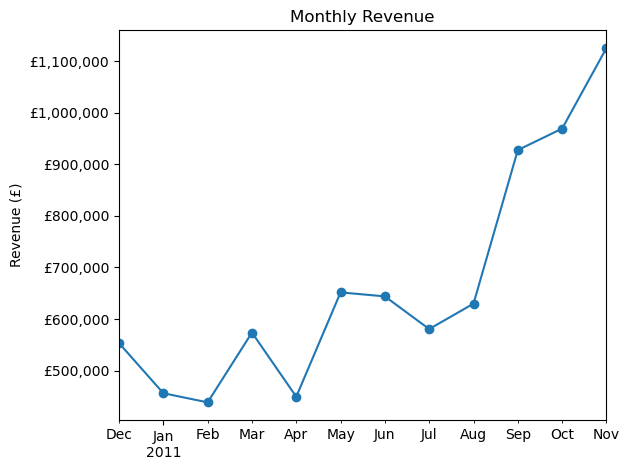

In [28]:
# Revenue over time
monthly_revenue = (
    clean.set_index("InvoiceDate")["TotalPrice"]
    .resample("MS")
    .sum()
)

fig, ax = plt.subplots()
monthly_revenue.plot(ax=ax, marker="o")
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue (£)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.show()

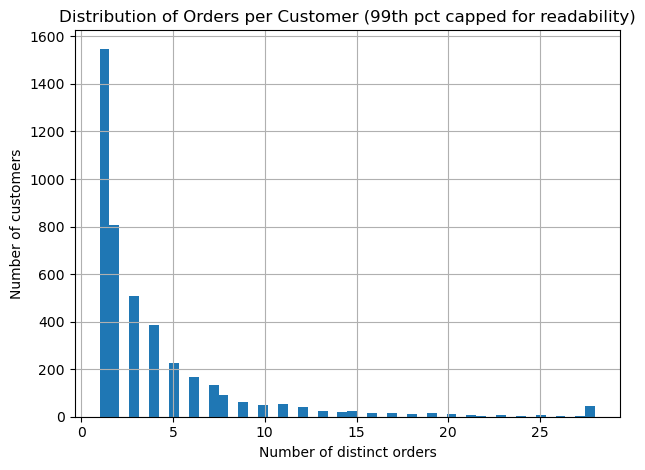

count    4283.000000
mean        4.086622
std         7.291791
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       195.000000
Name: InvoiceNo, dtype: float64


In [29]:
# Orders per customer -- highly skewed, as expected for retail
orders_per_customer = clean.groupby("CustomerID")["InvoiceNo"].nunique()

fig, ax = plt.subplots()
orders_per_customer.clip(upper=orders_per_customer.quantile(0.99)).hist(bins=50, ax=ax)
ax.set_title("Distribution of Orders per Customer (99th pct capped for readability)")
ax.set_xlabel("Number of distinct orders")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.show()

print(orders_per_customer.describe())

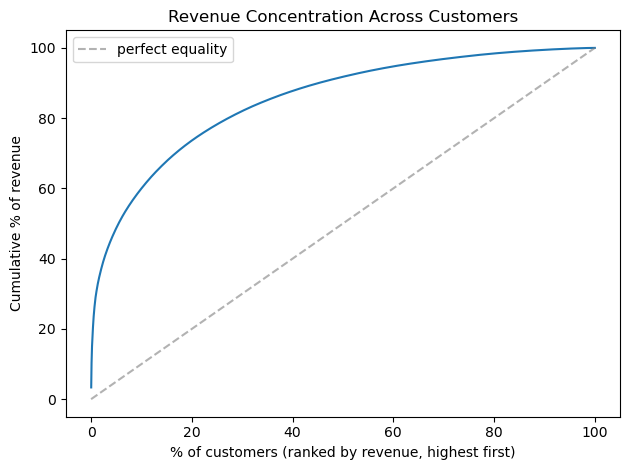

Top 10% of customers generate 60.0% of revenue


In [30]:
# Revenue concentration -- what % of revenue comes from the top X% of customers?
revenue_per_customer = clean.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)
cum_share = revenue_per_customer.cumsum() / revenue_per_customer.sum()
customer_share = np.arange(1, len(cum_share) + 1) / len(cum_share)

fig, ax = plt.subplots()
ax.plot(customer_share * 100, cum_share * 100)
ax.plot([0, 100], [0, 100], linestyle="--", color="grey", alpha=0.6, label="perfect equality")
ax.set_xlabel("% of customers (ranked by revenue, highest first)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Revenue Concentration Across Customers")
ax.legend()
plt.tight_layout()
plt.show()

top_10pct_share = cum_share.iloc[int(len(cum_share) * 0.10)]
print(f"Top 10% of customers generate {top_10pct_share*100:.1f}% of revenue")

##### Concentration curves shows that customers should not all be treated the same: a small share of customers drives a disproportionate share of revenue. 
##### A single average-CLV or churn threshold will provide an inaccurate view of a customer base

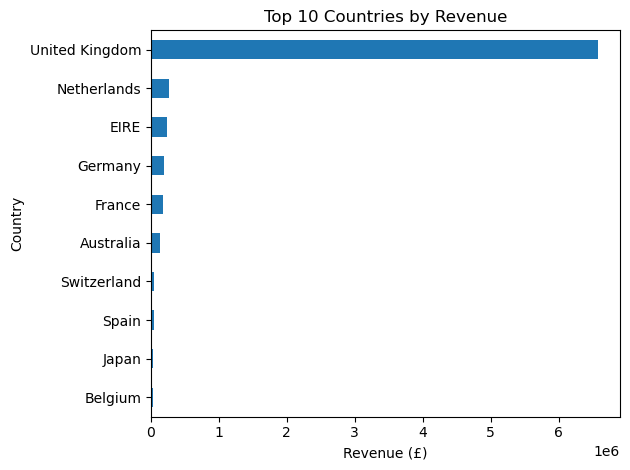

In [31]:
# Country mix (revenue-weighted)
country_revenue = (
    clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots()
country_revenue.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Revenue (£)")
#ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.show()

**Note:** the dataset is overwhelmingly UK-based. It may be worth restricting to UK customers only to avoid international shipping/pricing quirks confounding the CLV and churn signals. That decision is deferred to notebook 2,
where RFM and cohort structure are built — flagging it here so it isn't a silent choice later.

### Save data for next steps

Persisting the cleaned transaction table (plus the split-off cancellations table and Dec'11 snapshot tables, kept
for potential use as a churn/dissatisfaction signal later) for the rest of the
project. Parquet over CSV to preserve dtypes and keep it fast to reload.

In [32]:
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

clean.to_parquet(PROCESSED_DATA / "online_retail_clean.parquet", index=False)
cancellations.to_parquet(PROCESSED_DATA / "online_retail_cancellations.parquet", index=False)

with open(PROCESSED_DATA / "config.json", "w") as f:
    json.dump({"snapshot_date": snapshot_date.strftime("%Y-%m-%d")}, f, indent=2)

print("Saved:")
print(f"  initial_iteration/data/processed/online_retail_clean.parquet          {clean.shape}")
print(f"  initial_iteration/data/processed/online_retail_cancellations.parquet  {cancellations.shape}")
print(f"  initial_iteration/data/processed/config.json                          snapshot_date = {snapshot_date.date()}")


Saved:
  ../data/online_retail_clean.parquet          (371276, 9)
  ../data/online_retail_cancellations.parquet  (8905, 8)
  ../data/config.json                          snapshot_date = 2011-12-01


### Summary

- Started from the raw transaction table (see the `audit_df` table above for exact
  row counts) and retained a clean, analysis-ready set after removing missing-customer
  rows, cancellations, non-product line items, non-positive quantities/prices,
  exact duplicates, and incomplete months.
- Every cleaning decision is logged above with its rationale — important since each
  one has direct downstream effects on CLV and churn numbers.
- Revenue is highly concentrated across customers, which sets up the case for
  segmentation-based (not average-based) CLV work in the next notebook.
- Open question carried forward: whether to restrict to UK-only customers for the
  RFM/cohort/predictive modeling notebooks.

**Next:** `02_historic_clv_rfm_cohorts.ipynb` — Stupid Simple CLV, margin-adjusted CLV,
RFM segmentation, and cohort retention curves.